In [1]:
from scipy import stats
import pandas as pd
import pandas_datareader as web
import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
!pip install yfinance
import yfinance as yf

In [2]:
start = datetime.datetime(2021,1,1)
end = datetime.datetime(2022,1,1)

In [5]:
df_nse = yf.download('^NSEI', start=start, end=end)
df_nse

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-01,13996.099609,14049.849609,13991.349609,14018.500000,14018.500000,358100
2021-01-04,14104.349609,14147.950195,13953.750000,14132.900391,14132.900391,495000
2021-01-05,14075.150391,14215.599609,14048.150391,14199.500000,14199.500000,492500
2021-01-06,14240.950195,14244.150391,14039.900391,14146.250000,14146.250000,632300
2021-01-07,14253.750000,14256.250000,14123.099609,14137.349609,14137.349609,559200
...,...,...,...,...,...,...
2021-12-27,16937.750000,17112.050781,16833.199219,17086.250000,17086.250000,144800
2021-12-28,17177.599609,17250.250000,17161.150391,17233.250000,17233.250000,176000
2021-12-29,17220.099609,17285.949219,17176.650391,17213.599609,17213.599609,161700


In [6]:
df_stock= yf.download('BAJFINANCE.NS', start=start, end=end)
df_stock

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-01,5310.200195,5338.000000,5250.000000,5280.149902,5204.157227,1447187
2021-01-04,5324.000000,5324.000000,5196.200195,5216.200195,5141.127441,2333659
2021-01-05,5218.000000,5224.200195,5062.500000,5119.000000,5045.326660,3953400
2021-01-06,5130.000000,5168.350098,4990.299805,5030.299805,4957.902832,3607923
2021-01-07,5065.000000,5131.549805,5021.299805,5081.000000,5007.873047,3035750
...,...,...,...,...,...,...
2021-12-27,6751.000000,6908.799805,6654.049805,6890.750000,6802.550781,912360
2021-12-28,6980.000000,6980.000000,6861.750000,6906.649902,6818.247070,862464
2021-12-29,6884.899902,6949.950195,6853.049805,6911.649902,6823.183105,532379


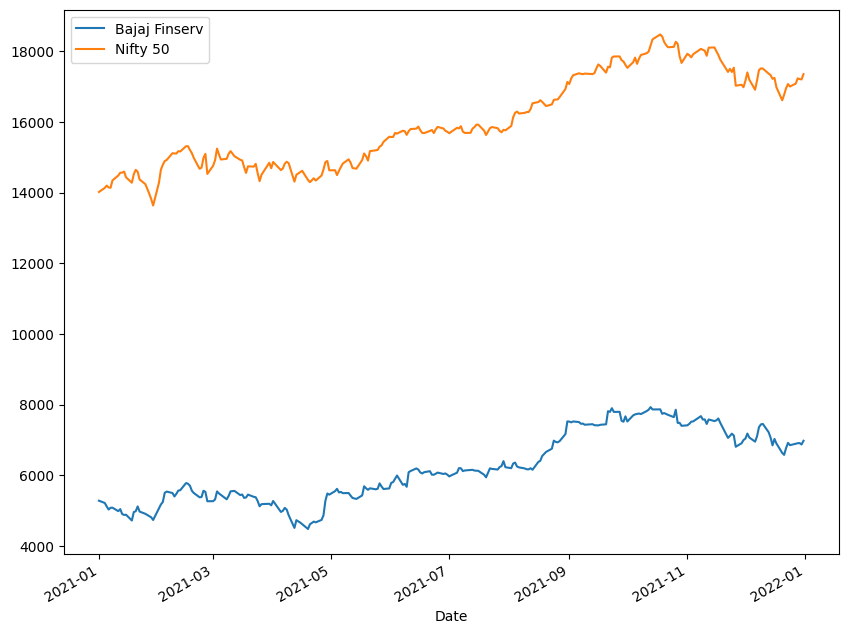

In [7]:
df_stock['Close'].plot(label = 'Bajaj Finserv', figsize=(10,8))
df_nse['Close'].plot(label = 'Nifty 50')
plt.legend()

In [8]:
df_stock['Cumu'] = df_stock['Close']/df_stock['Close'].iloc[0] #cumulative return, rrelative to Day0 closing.
df_nse['Cumu'] = df_nse['Close']/df_nse['Close'].iloc[0]

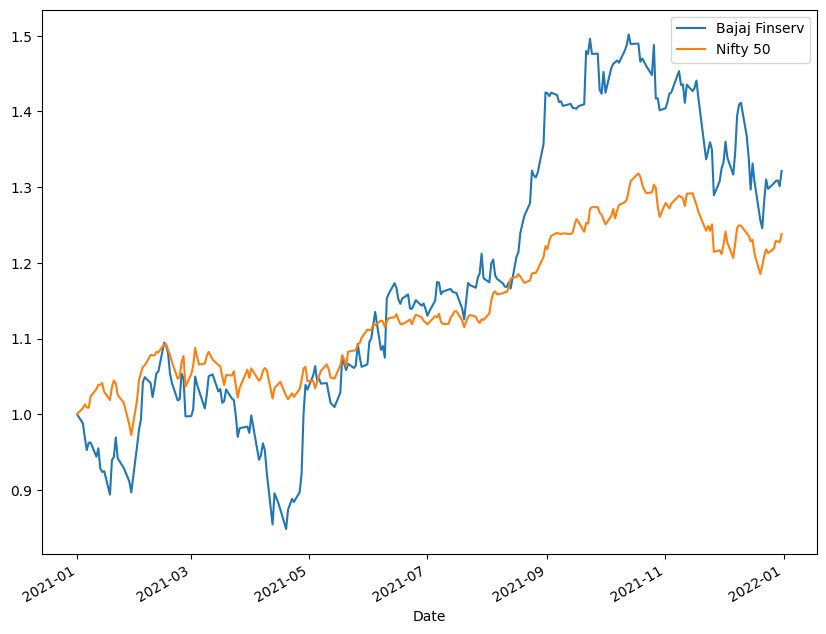

In [9]:
df_stock['Cumu'].plot(label = 'Bajaj Finserv', figsize=(10,8))
df_nse['Cumu'].plot(label = 'Nifty 50')
plt.legend()

In [10]:
df_stock['daily_ret'] = df_stock['Close'].pct_change(1)
df_nse['daily_ret'] = df_nse['Close'].pct_change(1)

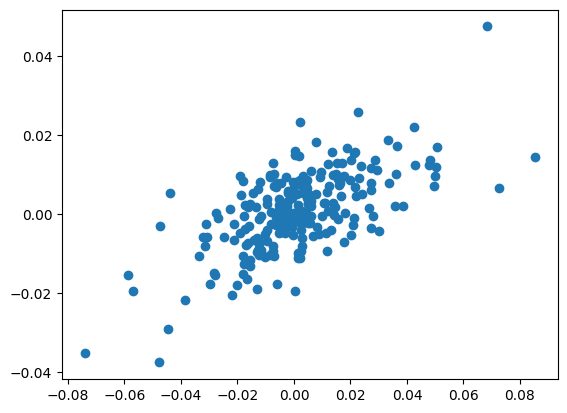

In [11]:
plt.scatter(df_stock['daily_ret'],df_nse['daily_ret'])

In [12]:
LR = stats.linregress(df_stock['daily_ret'].iloc[1:],df_nse['daily_ret'].iloc[1:])

In [13]:
beta,alpha,r_val,p_val,std_err = LR

In [14]:
beta

0.3028960742957345

In [15]:
alpha

0.0005058653732726757

In [19]:
date_1 = datetime.datetime(2022,5,11)
date_2 = datetime.datetime(2022,5,12)
df_stock_1 = yf.download('BAJFINANCE.NS',start=date_1,end=date_2)
df_stock_1.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-05-11,5957.0,5996.600098,5737.0,5807.0,5732.672363,1861339


In [20]:
original_return = df_stock_1.iloc[0].at["Close"]/df_stock.iloc[0].at["Close"]
original_return

1.0997793826691156

In [26]:
capm_return = 1 + beta * (df_stock.iloc[-1].at["Cumu"] - 1)
capm_return

1.097357092586165

In [27]:
(original_return - capm_return)*100/original_return

0.22025236343962762